# Group 4 Project - Success on the Next Quiz Attempt

## Main question

Can previous quiz activity predict success on a student's next attempt?

In [1]:
import pandas as pd

In [4]:
attempts = pd.read_json(
    "group_4_project/data/quiz_attempts.jsonl",
    lines=True
)

responses = pd.read_json(
    "group_4_project/data/quiz_item_responses.jsonl",
    lines=True
)

items = pd.read_json(
    "group_4_project/data/quiz_items.jsonl",
    lines=True
)

tasks = pd.read_json(
    "group_4_project/data/tasks.jsonl",
    lines=True
)

print("Quiz attempts:", attempts.shape)
print("Item responses:", responses.shape)
print("Quiz items:", items.shape)
print("Tasks:", tasks.shape)

Quiz attempts: (551, 28)
Item responses: (2735, 13)
Quiz items: (75, 12)
Tasks: (45, 17)


In [5]:
print("QUIZ ATTEMPTS")
print(attempts.columns.tolist())

print("\nITEM RESPONSES")
print(responses.columns.tolist())

print("\nQUIZ ITEMS")
print(items.columns.tolist())

print("\nTASKS")
print(tasks.columns.tolist())

QUIZ ATTEMPTS
['ambiguity_group_key', 'analysis_eligible', 'answered_item_count', 'attempt_key', 'attempt_resolution', 'attempt_sequence', 'attempt_status', 'available_item_points', 'course_key', 'duration_seconds', 'earned_item_points', 'item_count', 'lineage', 'quality_flags', 'quiz_purpose', 'record_origin', 'runtime_evidence_status', 'score_percent', 'source_started_at', 'source_submitted_at', 'source_timezone_known', 'started_at_local', 'started_at_utc', 'student_key', 'submitted_at_local', 'submitted_at_utc', 'task_key', 'timestamp_quality']

ITEM RESPONSES
['analysis_eligible', 'attempt_key', 'awarded_points', 'course_key', 'item_key', 'lineage', 'max_item_points', 'quality_flags', 'record_origin', 'response_status', 'score_proportion', 'student_key', 'task_key']

QUIZ ITEMS
['course_key', 'item_key', 'item_set_version', 'lineage', 'max_item_points', 'module_key', 'quality_flags', 'question_type', 'quiz_purpose', 'record_origin', 'submodule_key', 'task_key']

TASKS
['counts_for_

In [6]:
attempts.head()

,ambiguity_group_key,analysis_eligible,answered_item_count,attempt_key,attempt_resolution,attempt_sequence,attempt_status,available_item_points,course_key,duration_seconds,...,source_started_at,source_submitted_at,source_timezone_known,started_at_local,started_at_utc,student_key,submitted_at_local,submitted_at_utc,task_key,timestamp_quality
0,NaN,True,5,QATT-TASK-W01-01-STU-001-01,scope_time_match,1.0,submitted,5.0,CRS-001,520.0,...,2030-01-07 09:05:54,2030-01-07 09:14:34,True,2030-01-07T09:05:54+02:00,2030-01-07T07:05:54Z,STU-001,2030-01-07T09:14:34+02:00,2030-01-07T07:14:34Z,TASK-W01-01,writer_naive_mixed_known
1,NaN,True,5,QATT-TASK-W01-01-STU-003-01,scope_time_match,1.0,submitted,5.0,CRS-001,312.0,...,2030-01-07 09:12:28,2030-01-07 09:17:40,True,2030-01-07T09:12:28+02:00,2030-01-07T07:12:28Z,STU-003,2030-01-07T09:17:40+02:00,2030-01-07T07:17:40Z,TASK-W01-01,writer_naive_mixed_known
2,NaN,True,5,QATT-TASK-W01-01-STU-005-01,scope_time_match,1.0,submitted,5.0,CRS-001,496.0,...,2030-01-07 09:23:40,2030-01-07 09:31:56,True,2030-01-07T09:23:40+02:00,2030-01-07T07:23:40Z,STU-005,2030-01-07T09:31:56+02:00,2030-01-07T07:31:56Z,TASK-W01-01,writer_naive_mixed_known
3,NaN,True,5,QATT-TASK-W01-01-STU-006-01,scope_time_match,1.0,submitted,5.0,CRS-001,284.0,...,2030-01-07 09:13:47,2030-01-07 09:18:31,True,2030-01-07T09:13:47+02:00,2030-01-07T07:13:47Z,STU-006,2030-01-07T09:18:31+02:00,2030-01-07T07:18:31Z,TASK-W01-01,writer_naive_mixed_known
4,NaN,True,5,QATT-TASK-W01-01-STU-007-01,scope_time_match,1.0,submitted,5.0,CRS-001,422.0,...,2030-01-07 09:11:31,2030-01-07 09:18:33,True,2030-01-07T09:11:31+02:00,2030-01-07T07:11:31Z,STU-007,2030-01-07T09:18:33+02:00,2030-01-07T07:18:33Z,TASK-W01-01,writer_naive_mixed_known


In [7]:
for column in attempts.columns:
    print(column)

ambiguity_group_key
analysis_eligible
answered_item_count
attempt_key
attempt_resolution
attempt_sequence
attempt_status
available_item_points
course_key
duration_seconds
earned_item_points
item_count
lineage
quality_flags
quiz_purpose
record_origin
runtime_evidence_status
score_percent
source_started_at
source_submitted_at
source_timezone_known
started_at_local
started_at_utc
student_key
submitted_at_local
submitted_at_utc
task_key
timestamp_quality


## Understanding the quiz attempt data

I first checked the quiz attempt data and selected the columns that are useful for our project.

In [8]:
attempt_cols = [
    "student_key",
    "task_key",
    "attempt_key",
    "attempt_sequence",
    "score_percent",
    "duration_seconds",
    "answered_item_count",
    "analysis_eligible",
    "started_at_utc",
    "submitted_at_utc"
]

attempts[attempt_cols].head(10)

,student_key,task_key,attempt_key,attempt_sequence,score_percent,duration_seconds,answered_item_count,analysis_eligible,started_at_utc,submitted_at_utc
0,STU-001,TASK-W01-01,QATT-TASK-W01-01-STU-001-01,1.0,66.67,520.0,5,True,2030-01-07T07:05:54Z,2030-01-07T07:14:34Z
1,STU-003,TASK-W01-01,QATT-TASK-W01-01-STU-003-01,1.0,12.00,312.0,5,True,2030-01-07T07:12:28Z,2030-01-07T07:17:40Z
2,STU-005,TASK-W01-01,QATT-TASK-W01-01-STU-005-01,1.0,26.67,496.0,5,True,2030-01-07T07:23:40Z,2030-01-07T07:31:56Z
3,STU-006,TASK-W01-01,QATT-TASK-W01-01-STU-006-01,1.0,12.00,284.0,5,True,2030-01-07T07:13:47Z,2030-01-07T07:18:31Z
4,STU-007,TASK-W01-01,QATT-TASK-W01-01-STU-007-01,1.0,100.00,422.0,5,True,2030-01-07T07:11:31Z,2030-01-07T07:18:33Z
5,STU-008,TASK-W01-01,QATT-TASK-W01-01-STU-008-01,1.0,52.00,421.0,5,True,2030-01-07T07:02:29Z,2030-01-07T07:09:30Z
6,STU-009,TASK-W01-01,QATT-TASK-W01-01-STU-009-01,1.0,100.00,409.0,5,True,2030-01-07T07:15:01Z,2030-01-07T07:21:50Z
7,STU-010,TASK-W01-01,QATT-TASK-W01-01-STU-010-01,1.0,20.00,304.0,4,True,2030-01-07T07:23:23Z,2030-01-07T07:28:27Z
8,STU-012,TASK-W01-01,QATT-TASK-W01-01-STU-012-01,1.0,32.00,328.0,5,True,2030-01-07T07:15:07Z,2030-01-07T07:20:35Z
9,STU-014,TASK-W01-01,QATT-TASK-W01-01-STU-014-01,1.0,100.00,490.0,5,True,2030-01-07T07:09:15Z,2030-01-07T07:17:25Z


In [9]:
print("Total records:", len(attempts))
print("Eligible records:", attempts["analysis_eligible"].sum())
print("Students:", attempts["student_key"].nunique())
print("Quiz tasks:", attempts["task_key"].nunique())

print("\nAttempt sequence:")
print(attempts["attempt_sequence"].value_counts().sort_index())

Total records: 551
Eligible records: 537
Students: 40
Quiz tasks: 15

Attempt sequence:
attempt_sequence
1.0    507
2.0     42
Name: count, dtype: int64


## Preparing the attempt data

I kept only the records marked as eligible for analysis.

In [10]:
eligible_attempts = attempts[
    attempts["analysis_eligible"] == True
].copy()

print("Eligible records:", len(eligible_attempts))

print("\nAttempt sequence:")
print(
    eligible_attempts["attempt_sequence"]
    .value_counts(dropna=False)
    .sort_index()
)

Eligible records: 537

Attempt sequence:
attempt_sequence
1.0    495
2.0     42
Name: count, dtype: int64


In [11]:
repeated = eligible_attempts[
    eligible_attempts["attempt_sequence"] == 2
]

print("Second attempts:", len(repeated))
print("Students with second attempts:", repeated["student_key"].nunique())
print("Quizzes with second attempts:", repeated["task_key"].nunique())

Second attempts: 42
Students with second attempts: 27
Quizzes with second attempts: 15


In [12]:
repeated = eligible_attempts[
    eligible_attempts["attempt_sequence"] == 2
]

print("Second attempts:", len(repeated))
print("Students with second attempts:", repeated["student_key"].nunique())
print("Quizzes with second attempts:", repeated["task_key"].nunique())

Second attempts: 42
Students with second attempts: 27
Quizzes with second attempts: 15


In [13]:
repeated[
    ["student_key", "task_key", "attempt_sequence", "score_percent"]
].head(10)

,student_key,task_key,attempt_sequence,score_percent
28,STU-033,TASK-W01-01,2.0,60.00
53,STU-010,TASK-W02-03,2.0,40.00
77,STU-027,TASK-W02-02,2.0,100.00
87,STU-031,TASK-W02-03,2.0,60.00
90,STU-032,TASK-W02-03,2.0,40.00
125,STU-011,TASK-W03-02,2.0,32.00
144,STU-023,TASK-W03-03,2.0,60.00
153,STU-028,TASK-W03-02,2.0,40.00
189,STU-009,TASK-W04-03,2.0,46.67
194,STU-011,TASK-W04-03,2.0,40.00


## First and second attempt pairs

I matched each second attempt with the same student's first attempt on the same quiz.

In [14]:
first_attempts = eligible_attempts[
    eligible_attempts["attempt_sequence"] == 1
][
    ["student_key", "task_key", "score_percent", "duration_seconds"]
].copy()

second_attempts = eligible_attempts[
    eligible_attempts["attempt_sequence"] == 2
][
    ["student_key", "task_key", "score_percent", "duration_seconds"]
].copy()

pairs = first_attempts.merge(
    second_attempts,
    on=["student_key", "task_key"],
    suffixes=("_first", "_second")
)

print("Matched pairs:", len(pairs))

pairs.head(10)

Matched pairs: 42


,student_key,task_key,score_percent_first,duration_seconds_first,score_percent_second,duration_seconds_second
0,STU-033,TASK-W01-01,52.00,461.0,60.00,524.0
1,STU-010,TASK-W02-03,32.00,517.0,40.00,498.0
2,STU-027,TASK-W02-02,100.00,453.0,100.00,452.0
3,STU-031,TASK-W02-03,40.00,459.0,60.00,287.0
4,STU-032,TASK-W02-03,32.00,336.0,40.00,328.0
5,STU-011,TASK-W03-02,12.00,433.0,32.00,410.0
6,STU-023,TASK-W03-03,40.00,475.0,60.00,326.0
7,STU-028,TASK-W03-02,32.00,472.0,40.00,530.0
8,STU-009,TASK-W04-03,26.67,250.0,46.67,418.0
9,STU-011,TASK-W04-03,20.00,445.0,40.00,395.0


In [15]:
for column in tasks.columns:
    print(column)

counts_for_progress
course_key
deadline_at_local
max_points
module_key
planned_observation
record_origin
release_at_local
scope
source_submodule
source_theme
submodule_key
task_key
task_kind
task_type
week
grading_mode


In [16]:
tasks.head()

,counts_for_progress,course_key,deadline_at_local,max_points,module_key,planned_observation,record_origin,release_at_local,scope,source_submodule,source_theme,submodule_key,task_key,task_kind,task_type,week,grading_mode
0,True,CRS-001,2030-01-07T10:00:00+02:00,5,MOD-01,True,configuration,2030-01-07T09:00:00+02:00,individual,11.0,1.0,SUB-01-01,TASK-W01-01,quiz,technical_readiness,1.0,NaN
1,True,CRS-001,2030-01-07T15:30:00+02:00,5,MOD-01,True,configuration,2030-01-07T10:00:00+02:00,individual,11.0,1.0,SUB-01-01,TASK-W01-02,text,introductory_reflection,1.0,NaN
2,True,CRS-001,2030-01-07T15:45:00+02:00,10,MOD-01,True,configuration,2030-01-07T13:00:00+02:00,group,NaN,1.0,NaN,TASK-W01-03,text,group_kickoff,1.0,NaN
3,True,CRS-001,2030-01-14T09:30:00+02:00,10,MOD-02,True,configuration,2030-01-14T09:00:00+02:00,individual,21.0,2.0,SUB-02-01,TASK-W02-01,text,independent_study_submission,2.0,NaN
4,True,CRS-001,2030-01-14T10:00:00+02:00,10,MOD-02,True,configuration,2030-01-14T09:15:00+02:00,individual,21.0,2.0,SUB-02-01,TASK-W02-02,quiz,readiness_quiz,2.0,NaN


In [17]:
print("Second attempt scores:")
print(pairs["score_percent_second"].value_counts().sort_index())

print("\nScore summary:")
print(pairs["score_percent_second"].describe())

Second attempt scores:
score_percent_second
20.00      4
32.00      3
38.67      1
40.00     12
46.67      4
60.00      7
80.00      3
100.00     8
Name: count, dtype: int64

Score summary:
count     42.000000
mean      55.746429
std       26.113180
min       20.000000
25%       40.000000
50%       46.670000
75%       75.000000
max      100.000000
Name: score_percent_second, dtype: float64


In [18]:
pairs["score_change"] = (
    pairs["score_percent_second"] -
    pairs["score_percent_first"]
)

print(pairs["score_change"].describe())

count    42.000000
mean     12.412619
std      11.445116
min     -20.000000
25%       8.000000
50%      20.000000
75%      20.000000
max      20.000000
Name: score_change, dtype: float64


In [19]:
print("Second attempt scores:")
print(pairs["score_percent_second"].value_counts().sort_index())

print("\nScore summary:")
print(pairs["score_percent_second"].describe())

Second attempt scores:
score_percent_second
20.00      4
32.00      3
38.67      1
40.00     12
46.67      4
60.00      7
80.00      3
100.00     8
Name: count, dtype: int64

Score summary:
count     42.000000
mean      55.746429
std       26.113180
min       20.000000
25%       40.000000
50%       46.670000
75%       75.000000
max      100.000000
Name: score_percent_second, dtype: float64


## Defining success

I defined a successful next attempt as a second attempt with a higher score than the first attempt.

In [20]:
pairs["success"] = (
    pairs["score_percent_second"] > pairs["score_percent_first"]
).astype(int)

print(pairs["success"].value_counts())

print("\nSuccess rate:")
print(round(pairs["success"].mean() * 100, 1), "%")

success
1    32
0    10
Name: count, dtype: int64

Success rate:
76.2 %


In [21]:
pairs["success"] = (
    pairs["score_percent_second"] > pairs["score_percent_first"]
).astype(int)

print("Success counts:")
print(pairs["success"].value_counts())

print("\nSuccess rate:")
print(round(pairs["success"].mean() * 100, 1), "%")

Success counts:
success
1    32
0    10
Name: count, dtype: int64

Success rate:
76.2 %


## Previous attempt features

The prediction should only use information available before the second attempt.

In [22]:
pairs[
    [
        "student_key",
        "task_key",
        "score_percent_first",
        "duration_seconds_first",
        "success"
    ]
].head(10)

,student_key,task_key,score_percent_first,duration_seconds_first,success
0,STU-033,TASK-W01-01,52.00,461.0,1
1,STU-010,TASK-W02-03,32.00,517.0,1
2,STU-027,TASK-W02-02,100.00,453.0,0
3,STU-031,TASK-W02-03,40.00,459.0,1
4,STU-032,TASK-W02-03,32.00,336.0,1
5,STU-011,TASK-W03-02,12.00,433.0,1
6,STU-023,TASK-W03-03,40.00,475.0,1
7,STU-028,TASK-W03-02,32.00,472.0,1
8,STU-009,TASK-W04-03,26.67,250.0,1
9,STU-011,TASK-W04-03,20.00,445.0,1


In [23]:
print(
    pairs[
        ["score_percent_first", "duration_seconds_first", "success"]
    ].isna().sum()
)

score_percent_first       0
duration_seconds_first    0
success                   0
dtype: int64


In [24]:
for column in responses.columns:
    print(column)

analysis_eligible
attempt_key
awarded_points
course_key
item_key
lineage
max_item_points
quality_flags
record_origin
response_status
score_proportion
student_key
task_key


In [25]:
responses.head(10)

,analysis_eligible,attempt_key,awarded_points,course_key,item_key,lineage,max_item_points,quality_flags,record_origin,response_status,score_proportion,student_key,task_key
0,True,QATT-TASK-W01-01-STU-001-01,1.000000,CRS-001,QITEM-TASK-W01-01-01,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,full_credit,1.000000,STU-001,TASK-W01-01
1,True,QATT-TASK-W01-01-STU-001-01,1.000000,CRS-001,QITEM-TASK-W01-01-02,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,full_credit,1.000000,STU-001,TASK-W01-01
2,True,QATT-TASK-W01-01-STU-001-01,1.000000,CRS-001,QITEM-TASK-W01-01-03,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,full_credit,1.000000,STU-001,TASK-W01-01
3,True,QATT-TASK-W01-01-STU-001-01,0.333333,CRS-001,QITEM-TASK-W01-01-04,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,partial_credit,0.333333,STU-001,TASK-W01-01
4,True,QATT-TASK-W01-01-STU-001-01,0.000000,CRS-001,QITEM-TASK-W01-01-05,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,zero_credit,0.000000,STU-001,TASK-W01-01
5,True,QATT-TASK-W01-01-STU-003-01,0.000000,CRS-001,QITEM-TASK-W01-01-01,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,zero_credit,0.000000,STU-003,TASK-W01-01
6,True,QATT-TASK-W01-01-STU-003-01,0.600000,CRS-001,QITEM-TASK-W01-01-02,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,partial_credit,0.600000,STU-003,TASK-W01-01
7,True,QATT-TASK-W01-01-STU-003-01,0.000000,CRS-001,QITEM-TASK-W01-01-03,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,zero_credit,0.000000,STU-003,TASK-W01-01
8,True,QATT-TASK-W01-01-STU-003-01,0.000000,CRS-001,QITEM-TASK-W01-01-04,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,zero_credit,0.000000,STU-003,TASK-W01-01
9,True,QATT-TASK-W01-01-STU-003-01,0.000000,CRS-001,QITEM-TASK-W01-01-05,"{'lineage_quality': 'exact', 'source_record_co...",1,[],source_quiz_item_evidence_scan,zero_credit,0.000000,STU-003,TASK-W01-01


In [26]:
eligible_responses = responses[
    responses["analysis_eligible"] == True
].copy()

print("Eligible item responses:", len(eligible_responses))

Eligible item responses: 2685


In [27]:
item_features = eligible_responses.groupby("attempt_key").agg(
    avg_item_score=("score_proportion", "mean"),
    min_item_score=("score_proportion", "min"),
    max_item_score=("score_proportion", "max"),
    items_answered=("item_key", "count")
).reset_index()

item_features.head()

,attempt_key,avg_item_score,min_item_score,max_item_score,items_answered
0,QATT-TASK-W01-01-STU-001-01,0.666667,0.0,1.0,5
1,QATT-TASK-W01-01-STU-003-01,0.120000,0.0,0.6,5
2,QATT-TASK-W01-01-STU-005-01,0.266667,0.0,1.0,5
3,QATT-TASK-W01-01-STU-006-01,0.120000,0.0,0.6,5
4,QATT-TASK-W01-01-STU-007-01,1.000000,1.0,1.0,5


In [28]:
first_attempts = eligible_attempts[
    eligible_attempts["attempt_sequence"] == 1
][
    [
        "student_key",
        "task_key",
        "attempt_key",
        "score_percent",
        "duration_seconds"
    ]
].copy()

In [29]:
second_attempts = eligible_attempts[
    eligible_attempts["attempt_sequence"] == 2
][
    [
        "student_key",
        "task_key",
        "score_percent",
        "duration_seconds"
    ]
].copy()

pairs = first_attempts.merge(
    second_attempts,
    on=["student_key", "task_key"],
    suffixes=("_first", "_second")
)

pairs["success"] = (
    pairs["score_percent_second"] > pairs["score_percent_first"]
).astype(int)

print("Matched pairs:", len(pairs))

Matched pairs: 42


In [30]:
project_data = pairs.merge(
    item_features,
    left_on="attempt_key",
    right_on="attempt_key",
    how="left"
)

project_data[
    [
        "student_key",
        "task_key",
        "score_percent_first",
        "duration_seconds_first",
        "avg_item_score",
        "min_item_score",
        "max_item_score",
        "items_answered",
        "success"
    ]
].head(10)

,student_key,task_key,score_percent_first,duration_seconds_first,avg_item_score,min_item_score,max_item_score,items_answered,success
0,STU-033,TASK-W01-01,52.00,461.0,0.520000,0.0,1.0,5,1
1,STU-010,TASK-W02-03,32.00,517.0,0.320000,0.0,1.0,5,1
2,STU-027,TASK-W02-02,100.00,453.0,1.000000,1.0,1.0,5,0
3,STU-031,TASK-W02-03,40.00,459.0,0.400000,0.0,1.0,5,1
4,STU-032,TASK-W02-03,32.00,336.0,0.320000,0.0,1.0,5,1
5,STU-011,TASK-W03-02,12.00,433.0,0.120000,0.0,0.6,5,1
6,STU-023,TASK-W03-03,40.00,475.0,0.400000,0.0,1.0,5,1
7,STU-028,TASK-W03-02,32.00,472.0,0.320000,0.0,1.0,5,1
8,STU-009,TASK-W04-03,26.67,250.0,0.266667,0.0,1.0,5,1
9,STU-011,TASK-W04-03,20.00,445.0,0.200000,0.0,1.0,5,1


In [31]:
print("Rows:", len(project_data))

print("\nMissing values:")
print(
    project_data[
        [
            "score_percent_first",
            "duration_seconds_first",
            "avg_item_score",
            "min_item_score",
            "max_item_score",
            "items_answered",
            "success"
        ]
    ].isna().sum()
)

Rows: 42

Missing values:
score_percent_first       0
duration_seconds_first    0
avg_item_score            0
min_item_score            0
max_item_score            0
items_answered            0
success                   0
dtype: int64


In [32]:
quiz_tasks = tasks[
    tasks["task_key"].isin(project_data["task_key"])
][
    ["task_key", "week", "task_type"]
]

quiz_tasks.head(10)

,task_key,week,task_type
0,TASK-W01-01,1.0,technical_readiness
4,TASK-W02-02,2.0,readiness_quiz
5,TASK-W02-03,2.0,practical_verification_quiz
9,TASK-W03-02,3.0,readiness_quiz
10,TASK-W03-03,3.0,practical_verification_quiz
14,TASK-W04-02,4.0,readiness_quiz
15,TASK-W04-03,4.0,practical_verification_quiz
19,TASK-W05-02,5.0,readiness_quiz
20,TASK-W05-03,5.0,practical_verification_quiz
24,TASK-W06-02,6.0,readiness_quiz


In [33]:
print(quiz_tasks["task_type"].value_counts())
print("\nWeeks:")
print(quiz_tasks["week"].value_counts().sort_index())

task_type
readiness_quiz                 7
practical_verification_quiz    7
technical_readiness            1
Name: count, dtype: int64

Weeks:
week
1.0    1
2.0    2
3.0    2
4.0    2
5.0    2
6.0    2
7.0    2
8.0    2
Name: count, dtype: int64


In [34]:
project_data = project_data.merge(
    quiz_tasks,
    on="task_key",
    how="left"
)

print("Rows:", len(project_data))
print("Missing week:", project_data["week"].isna().sum())

project_data[
    [
        "student_key",
        "task_key",
        "week",
        "task_type",
        "score_percent_first",
        "duration_seconds_first",
        "avg_item_score",
        "success"
    ]
].head(10)

Rows: 42
Missing week: 0


,student_key,task_key,week,task_type,score_percent_first,duration_seconds_first,avg_item_score,success
0,STU-033,TASK-W01-01,1.0,technical_readiness,52.00,461.0,0.520000,1
1,STU-010,TASK-W02-03,2.0,practical_verification_quiz,32.00,517.0,0.320000,1
2,STU-027,TASK-W02-02,2.0,readiness_quiz,100.00,453.0,1.000000,0
3,STU-031,TASK-W02-03,2.0,practical_verification_quiz,40.00,459.0,0.400000,1
4,STU-032,TASK-W02-03,2.0,practical_verification_quiz,32.00,336.0,0.320000,1
5,STU-011,TASK-W03-02,3.0,readiness_quiz,12.00,433.0,0.120000,1
6,STU-023,TASK-W03-03,3.0,practical_verification_quiz,40.00,475.0,0.400000,1
7,STU-028,TASK-W03-02,3.0,readiness_quiz,32.00,472.0,0.320000,1
8,STU-009,TASK-W04-03,4.0,practical_verification_quiz,26.67,250.0,0.266667,1
9,STU-011,TASK-W04-03,4.0,practical_verification_quiz,20.00,445.0,0.200000,1


In [35]:
print("Success:")
print(project_data["success"].value_counts())

print("\nWeeks:")
print(project_data["week"].value_counts().sort_index())

Success:
success
1    32
0    10
Name: count, dtype: int64

Weeks:
week
1.0     1
2.0     4
3.0     3
4.0     7
5.0    10
6.0     6
7.0     9
8.0     2
Name: count, dtype: int64


In [36]:
features = [
    "score_percent_first",
    "duration_seconds_first",
    "avg_item_score",
    "min_item_score",
    "max_item_score",
    "items_answered",
    "week",
    "success"
]

project_data[features].describe().round(2)

,score_percent_first,duration_seconds_first,avg_item_score,min_item_score,max_item_score,items_answered,week,success
count,42.00,42.00,42.00,42.00,42.00,42.0,42.00,42.00
mean,43.33,390.21,0.43,0.17,0.94,5.0,5.02,0.76
std,29.89,81.06,0.30,0.38,0.19,0.0,1.79,0.43
min,0.00,246.00,0.00,0.00,0.00,5.0,1.00,0.00
25%,20.00,338.50,0.20,0.00,1.00,5.0,4.00,1.00
50%,32.00,393.50,0.32,0.00,1.00,5.0,5.00,1.00
75%,58.00,460.50,0.58,0.00,1.00,5.0,6.75,1.00
max,100.00,517.00,1.00,1.00,1.00,5.0,8.00,1.00


In [37]:
project_data[features].corr().round(2)

,score_percent_first,duration_seconds_first,avg_item_score,min_item_score,max_item_score,items_answered,week,success
score_percent_first,1.00,0.07,1.00,0.86,0.39,NaN,-0.14,-0.72
duration_seconds_first,0.07,1.00,0.07,0.15,-0.19,NaN,-0.41,-0.04
avg_item_score,1.00,0.07,1.00,0.86,0.39,NaN,-0.14,-0.72
min_item_score,0.86,0.15,0.86,1.00,0.15,NaN,-0.08,-0.80
max_item_score,0.39,-0.19,0.39,0.15,1.00,NaN,-0.17,-0.18
items_answered,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
week,-0.14,-0.41,-0.14,-0.08,-0.17,NaN,1.00,-0.06
success,-0.72,-0.04,-0.72,-0.80,-0.18,NaN,-0.06,1.00


In [38]:
model_features = [
    "score_percent_first",
    "duration_seconds_first",
    "week"
]

X = project_data[model_features]
y = project_data["success"]

print(X.head())
print("\nTarget:")
print(y.value_counts())

   score_percent_first  duration_seconds_first  week
0                 52.0                   461.0   1.0
1                 32.0                   517.0   2.0
2                100.0                   453.0   2.0
3                 40.0                   459.0   2.0
4                 32.0                   336.0   2.0

Target:
success
1    32
0    10
Name: count, dtype: int64


## Train/test split and baseline

I split the data into training and test sets. I used stratify because the success classes are not balanced.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTest target:")
print(y_test.value_counts())

Training rows: 31
Test rows: 11

Training target:
success
1    24
0     7
Name: count, dtype: int64

Test target:
success
1    8
0    3
Name: count, dtype: int64


In [40]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("Baseline accuracy:", round(accuracy_score(y_test, dummy_pred), 2))

Baseline accuracy: 0.73


In [41]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

baseline_accuracy = accuracy_score(y_test, dummy_pred)

print("Baseline accuracy:", round(baseline_accuracy, 2))

Baseline accuracy: 0.73


## Logistic Regression

I trained Logistic Regression using the first attempt score, duration and course week.

In [42]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

model_accuracy = accuracy_score(y_test, pred)

print("Baseline accuracy:", round(baseline_accuracy, 2))
print("Logistic Regression accuracy:", round(model_accuracy, 2))

Baseline accuracy: 0.73
Logistic Regression accuracy: 0.82


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification report:")
print(classification_report(y_test, pred))

Confusion matrix:
[[2 1]
 [1 7]]

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.88      0.88      0.88         8

    accuracy                           0.82        11
   macro avg       0.77      0.77      0.77        11
weighted avg       0.82      0.82      0.82        11



### Result

Logistic Regression reached 82% accuracy compared with 73% for the baseline.

The model correctly predicted 9 of 11 test cases. It correctly identified 7 of 8 successful attempts and 2 of 3 unsuccessful attempts.

The result is better than the baseline, but the test set is very small, so the result should be interpreted carefully.

In [44]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Baseline:", round(baseline_accuracy, 2))
print("Logistic Regression:", round(model_accuracy, 2))
print("Decision Tree:", round(tree_accuracy, 2))

print("\nDecision Tree confusion matrix:")
print(confusion_matrix(y_test, tree_pred))

Baseline: 0.73
Logistic Regression: 0.82
Decision Tree: 0.73

Decision Tree confusion matrix:
[[2 1]
 [2 6]]


### Model comparison

Logistic Regression gave the best result with 82% accuracy.

The baseline and Decision Tree both gave 73% accuracy. Logistic Regression correctly predicted 9 of the 11 test cases.

The test set is small, so one wrong prediction changes the accuracy a lot.

## Student-grouped validation

The same student can have more than one observation. I tested a student-grouped split so that the same student does not appear in both training and test data.

In [45]:
from sklearn.model_selection import GroupShuffleSplit

groups = project_data["student_key"]

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups)
)

X_train_group = X.iloc[train_idx]
X_test_group = X.iloc[test_idx]

y_train_group = y.iloc[train_idx]
y_test_group = y.iloc[test_idx]

print("Training rows:", len(X_train_group))
print("Test rows:", len(X_test_group))

print("Training students:", groups.iloc[train_idx].nunique())
print("Test students:", groups.iloc[test_idx].nunique())

print(
    "Students in both:",
    len(
        set(groups.iloc[train_idx]) &
        set(groups.iloc[test_idx])
    )
)

Training rows: 33
Test rows: 9
Training students: 20
Test students: 7
Students in both: 0


In [46]:
# Baseline with grouped split
dummy_group = DummyClassifier(strategy="most_frequent")
dummy_group.fit(X_train_group, y_train_group)

dummy_group_pred = dummy_group.predict(X_test_group)

group_baseline_accuracy = accuracy_score(
    y_test_group,
    dummy_group_pred
)


# Logistic Regression with grouped split
model_group = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

model_group.fit(X_train_group, y_train_group)

group_pred = model_group.predict(X_test_group)

group_model_accuracy = accuracy_score(
    y_test_group,
    group_pred
)


print("Grouped baseline accuracy:",
      round(group_baseline_accuracy, 2))

print("Grouped Logistic Regression accuracy:",
      round(group_model_accuracy, 2))

print("\nConfusion matrix:")
print(confusion_matrix(y_test_group, group_pred))

print("\nActual test classes:")
print(y_test_group.value_counts())

Grouped baseline accuracy: 0.44
Grouped Logistic Regression accuracy: 0.89

Confusion matrix:
[[4 1]
 [0 4]]

Actual test classes:
success
0    5
1    4
Name: count, dtype: int64


### Student-grouped validation result

With the student-grouped split, Logistic Regression reached 89% accuracy, while the baseline reached 44%.

The model correctly predicted 8 of 9 test cases. There were no students shared between the training and test sets.

This suggests that the model can also make predictions for unseen students. However, the dataset and test set are small, so the result should not be treated as a strong general conclusion.

## Model interpretation

I checked the Logistic Regression coefficients to see how each feature affected the prediction.

In [47]:
import pandas as pd

coefficients = model_group.named_steps["logisticregression"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": model_features,
    "coefficient": coefficients
})

feature_importance["abs_coefficient"] = feature_importance["coefficient"].abs()

feature_importance = feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

print(feature_importance)

                  feature  coefficient  abs_coefficient
0     score_percent_first    -1.293725         1.293725
2                    week    -0.376047         0.376047
1  duration_seconds_first    -0.064421         0.064421


### Feature interpretation

The first attempt score had the strongest effect on the prediction. Its coefficient was negative, meaning that students with higher first attempt scores were less likely to improve on the second attempt.

Week had a smaller negative effect, while first attempt duration had very little effect.

This does not mean that a high first score causes failure. In this project, success was defined as improving the first score, so students with already high scores had less room to improve.

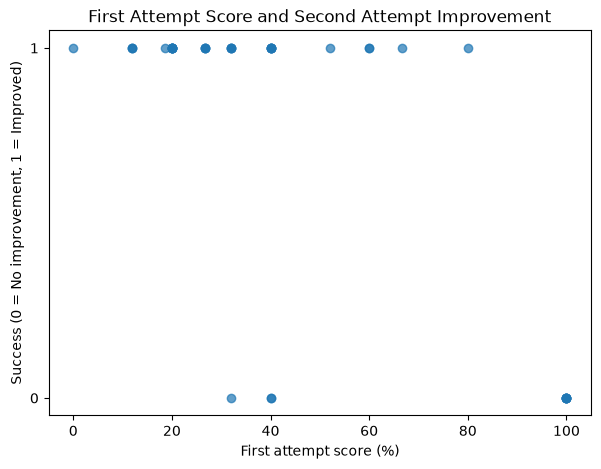

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    project_data["score_percent_first"],
    project_data["success"],
    alpha=0.7
)

plt.xlabel("First attempt score (%)")
plt.ylabel("Success (0 = No improvement, 1 = Improved)")
plt.title("First Attempt Score and Second Attempt Improvement")
plt.yticks([0, 1])

plt.show()

### Visualization observation

The plot shows that improvement happened more often when the first attempt score was lower. Students with high first attempt scores had less room to improve.

This supports the negative coefficient found in Logistic Regression.

In [49]:
results = project_data.iloc[test_idx][
    ["student_key", "task_key", "score_percent_first",
     "duration_seconds_first", "week", "success"]
].copy()

results["predicted"] = group_pred

wrong_predictions = results[
    results["success"] != results["predicted"]
]

print(wrong_predictions)

   student_key     task_key  score_percent_first  duration_seconds_first  \
31     STU-001  TASK-W07-02                 32.0                   310.0   

    week  success  predicted  
31   7.0        0          1  


### Misclassified case

The grouped Logistic Regression made one wrong prediction.

The student had a first attempt score of 32% in week 7. The model predicted that the student would improve, but the student did not improve.

The student's score decreased from 32% to 20%, so the case was correctly labelled as no improvement.

The model probably predicted improvement because lower first attempt scores were strongly associated with improvement in this dataset. This case shows that the first attempt score alone cannot explain every student's next attempt.

In [50]:
project_data.loc[
    31,
    [
        "student_key",
        "task_key",
        "score_percent_first",
        "score_percent_second",
        "success"
    ]
]

student_key                 STU-001
task_key                TASK-W07-02
score_percent_first            32.0
score_percent_second           20.0
success                           0
Name: 31, dtype: object

## Limitations and leakage

Only information available before the second attempt was used as model input. Second attempt score and duration were not used as predictors because this would cause data leakage.

The dataset is small, with only 42 second-attempt cases from 27 students. Because of this, model accuracy can change a lot depending on the train/test split.

I also used student-grouped validation so that the same student was not present in both training and test data.

Success was defined as getting a higher score on the second attempt. This creates a limitation because students with high first attempt scores have less room to improve. For example, a student scoring 100% on both attempts is labelled as no improvement even though the performance is good.

The results show prediction patterns in this synthetic dataset. They should not be interpreted as causal relationships.

In [51]:
project_data.to_csv(
    "group_4_project/data/analytical_dataset.csv",
    index=False
)

print("Analytical dataset saved.")

Analytical dataset saved.


## Comparison with the synthetic data documentation

The dataset documentation confirms that the data are fully artificial. The dataset contains 40 students and 551 quiz attempts.

The documentation does not provide a completed reference analysis or a hidden expected result for this prediction task. Therefore, I cannot conclude that the relationships found by my model were intentionally generated.

My analysis found that the first attempt score was the strongest predictor of improvement. However, this is also affected by how I defined success: students with high first attempt scores have less room to improve.

The documentation also notes that repeated learner observations need careful splitting. I addressed this by using student-grouped validation so that the same student was not included in both training and test data.

## Conclusion

The goal was to predict whether a student's second quiz attempt would improve compared with the first attempt.

The final dataset contained 42 second-attempt cases. Logistic Regression performed better than the baseline and Decision Tree. With the student-grouped split, Logistic Regression reached 89% accuracy and correctly predicted 8 of 9 cases.

The first attempt score was the strongest predictor. Lower first attempt scores were more often followed by improvement, while duration and course week had much smaller effects.

However, the dataset is small and fully artificial. The definition of success also creates a ceiling effect because students with high first attempt scores have less room to improve. Therefore, the results show patterns in this dataset and should not be interpreted as causal conclusions.